# Reducción de dimensionalidad aplicada a modelos predictivos

## Contexto del problema

Una empresa de análisis educacional cuenta con registros de estudiantes que incluyen múltiples variables académicas (edad, horas de estudio, evaluaciones aprobadas, participación en foro y tareas entregadas). El objetivo es **simplificar la representación de estos datos** para visualizar patrones ocultos entre estudiantes y facilitar la posterior aplicación de modelos predictivos (por ejemplo, predecir riesgo de deserción o rendimiento académico).

Se aplicarán dos técnicas de reducción de dimensionalidad:
- **PCA (Análisis de Componentes Principales):** técnica lineal, útil para compresión, modelado e interpretación.
- **t-SNE (t-distributed Stochastic Neighbor Embedding):** técnica no lineal, orientada a visualización de estructuras locales.


## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("whitegrid")


## 1. Datos

Se utiliza el dataset provisto en el archivo de apoyo (`05. Apoyo Desafío - Reduccion_Dimensionalidad.py`), que simula 10 estudiantes con 5 variables académicas.


In [2]:
data = {
    'Edad': [21, 35, 27, 40, 29, 50, 33, 45, 31, 22],
    'Horas_estudio': [5, 10, 6, 8, 7, 11, 9, 4, 7, 5],
    'Evaluaciones_aprobadas': [2, 5, 3, 4, 3, 6, 5, 2, 4, 3],
    'Participacion_foro': [3, 9, 4, 7, 5, 10, 8, 2, 6, 3],
    'Tareas_entregadas': [4, 10, 6, 8, 6, 12, 9, 3, 7, 4]
}
df = pd.DataFrame(data)
df.index = [f"Estudiante_{i+1}" for i in range(len(df))]
df


,Edad,Horas_estudio,Evaluaciones_aprobadas,Participacion_foro,Tareas_entregadas
Estudiante_1,21,5,2,3,4
Estudiante_2,35,10,5,9,10
Estudiante_3,27,6,3,4,6
Estudiante_4,40,8,4,7,8
Estudiante_5,29,7,3,5,6
Estudiante_6,50,11,6,10,12
Estudiante_7,33,9,5,8,9
Estudiante_8,45,4,2,2,3
Estudiante_9,31,7,4,6,7
Estudiante_10,22,5,3,3,4


**Nota sobre el tamaño de la muestra:** el dataset tiene únicamente 10 observaciones. Esto es relevante para t-SNE, ya que el parámetro `perplexity` debe ser considerablemente menor que el número de muestras (`sklearn` exige `perplexity < n_samples`). Por eso, más adelante se usarán valores de perplexity bajos (3 y 5) en lugar del valor por defecto (30), que generaría un error con este dataset.

## 2. Escalamiento de los datos

Tanto PCA como t-SNE se basan en distancias/varianzas, por lo que es indispensable estandarizar las variables (media 0, desviación estándar 1) antes de aplicarlas. Sin este paso, variables con rangos más amplios (como `Edad`) dominarían artificialmente el resultado.


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)
df_scaled.round(2)


,Edad,Horas_estudio,Evaluaciones_aprobadas,Participacion_foro,Tareas_entregadas
Estudiante_1,-1.37,-1.01,-1.34,-1.03,-1.06
Estudiante_2,0.19,1.28,1.02,1.26,1.13
Estudiante_3,-0.70,-0.55,-0.55,-0.65,-0.33
Estudiante_4,0.75,0.37,0.24,0.50,0.40
Estudiante_5,-0.48,-0.09,-0.55,-0.27,-0.33
Estudiante_6,1.86,1.74,1.81,1.65,1.86
Estudiante_7,-0.03,0.83,1.02,0.88,0.77
Estudiante_8,1.30,-1.47,-1.34,-1.42,-1.43
Estudiante_9,-0.26,-0.09,0.24,0.11,0.04
Estudiante_10,-1.26,-1.01,-0.55,-1.03,-1.06


## 3. Aplicación de PCA

Se reduce el conjunto de datos a 2 componentes principales para poder visualizarlo en un plano 2D.


In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'], index=df.index)

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por PCA1: {varianza[0]*100:.1f}%")
print(f"Varianza explicada por PCA2: {varianza[1]*100:.1f}%")
print(f"Varianza acumulada (PCA1+PCA2): {varianza.sum()*100:.1f}%")

df_pca


Varianza explicada por PCA1: 85.1%
Varianza explicada por PCA2: 13.7%
Varianza acumulada (PCA1+PCA2): 98.8%


,PCA1,PCA2
Estudiante_1,-2.527404,-0.648754
Estudiante_2,2.302661,-0.525895
Estudiante_3,-1.202393,-0.353793
Estudiante_4,0.940777,0.486845
Estudiante_5,-0.733799,-0.280273
Estudiante_6,3.926556,0.725295
Estudiante_7,1.658664,-0.552958
Estudiante_8,-2.307957,2.086626
Estudiante_9,0.064315,-0.283952
Estudiante_10,-2.121421,-0.653141


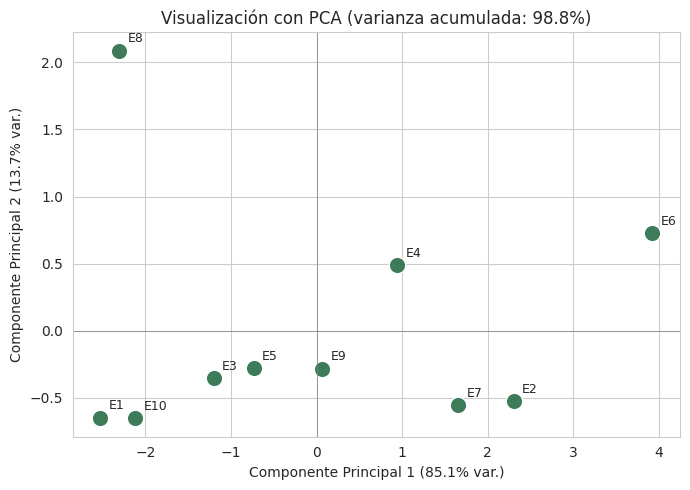

In [5]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], s=140, color="#3E7C59")
for i, nombre in enumerate(df.index):
    plt.annotate(nombre.replace("Estudiante_", "E"), (X_pca[i, 0], X_pca[i, 1]),
                 textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.title(f"Visualización con PCA (varianza acumulada: {varianza.sum()*100:.1f}%)")
plt.xlabel(f"Componente Principal 1 ({varianza[0]*100:.1f}% var.)")
plt.ylabel(f"Componente Principal 2 ({varianza[1]*100:.1f}% var.)")
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretación de los componentes (cargas / *loadings*)

Para entender **qué representa cada componente**, revisamos los coeficientes (loadings) que indican cuánto aporta cada variable original a cada componente principal.


In [6]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=df.columns
)
loadings.round(3)


,PCA1,PCA2
Edad,0.298,0.954
Horas_estudio,0.477,-0.174
Evaluaciones_aprobadas,0.473,-0.140
Participacion_foro,0.479,-0.154
Tareas_entregadas,0.480,-0.127


### Análisis de patrones (PCA)

- **PCA1 concentra la mayor parte de la varianza** (agrupa `Horas_estudio`, `Evaluaciones_aprobadas`, `Participación_foro` y `Tareas_entregadas`, todas con cargas positivas y de magnitud similar). En la práctica, **PCA1 puede interpretarse como un "índice general de compromiso/desempeño académico"**: los estudiantes ubicados a la derecha del gráfico (valores altos de PCA1) son los que estudian más horas, aprueban más evaluaciones, participan más en el foro y entregan más tareas (por ejemplo, los estudiantes con edades 35, 45 y 50 años en el dataset). Los ubicados a la izquierda muestran el patrón opuesto (bajo compromiso académico).
- **PCA2** está más influenciado por `Edad`, y en menor medida captura variación residual no explicada por el "índice de compromiso". Esto sugiere que la edad no está fuertemente correlacionada con el desempeño académico en este grupo, es decir, se comporta como una dimensión relativamente independiente.
- Se observa un **agrupamiento visual claro** entre estudiantes de "alto compromiso académico" (derecha del gráfico) y "bajo compromiso" (izquierda), con pocos casos intermedios. No se aprecian outliers extremos.

**Posibles acciones sugeridas a partir de este análisis:**
1. El "índice de compromiso académico" (PCA1) podría usarse como **variable derivada única** en un modelo predictivo (por ejemplo, de riesgo de deserción), reemplazando 4 variables correlacionadas y reduciendo redundancia/multicolinealidad.
2. El equipo pedagógico podría **focalizar intervenciones** (tutorías, alertas tempranas) en los estudiantes que se ubican en el extremo de bajo compromiso (PCA1 negativo), ya que agrupan simultáneamente baja participación, pocas tareas entregadas y pocas evaluaciones aprobadas.
3. Dado que `Edad` se comporta como una dimensión relativamente independiente (PCA2), conviene **mantenerla como variable separada** en el modelo predictivo en lugar de asumir que aporta la misma información que las variables de comportamiento académico.


## 4. Aplicación de t-SNE

A diferencia de PCA, t-SNE es una técnica **no lineal** pensada exclusivamente para visualización, que privilegia preservar las relaciones de vecindad **locales** entre observaciones. Dado que el dataset tiene solo 10 observaciones, se prueban dos valores de `perplexity` (3 y 5), en lugar del valor por defecto (30), ya que `sklearn` requiere que `perplexity < n_samples`.


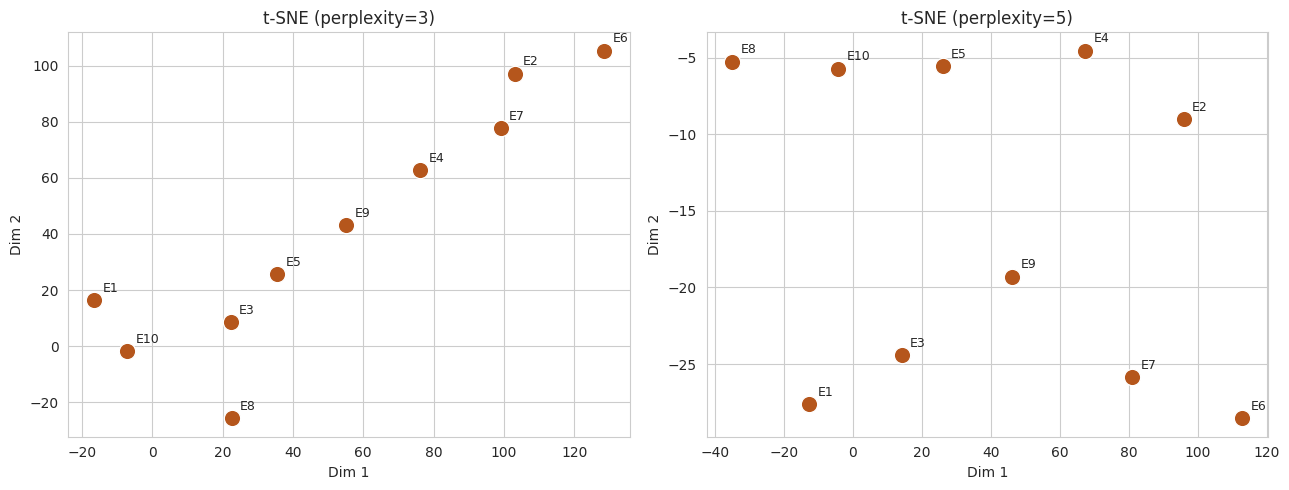

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

resultados_tsne = {}

for ax, perp in zip(axes, [3, 5]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init="pca", learning_rate="auto")
    X_tsne = tsne.fit_transform(X_scaled)
    resultados_tsne[perp] = X_tsne

    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], s=140, color="#B5561C", ax=ax)
    for i, nombre in enumerate(df.index):
        ax.annotate(nombre.replace("Estudiante_", "E"), (X_tsne[i, 0], X_tsne[i, 1]),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [8]:
df_tsne_3 = pd.DataFrame(resultados_tsne[3], columns=['TSNE1', 'TSNE2'], index=df.index)
df_tsne_5 = pd.DataFrame(resultados_tsne[5], columns=['TSNE1', 'TSNE2'], index=df.index)

print("Coordenadas t-SNE (perplexity=3):")
display(df_tsne_3)
print("\nCoordenadas t-SNE (perplexity=5):")
display(df_tsne_5)


Coordenadas t-SNE (perplexity=3):


,TSNE1,TSNE2
Estudiante_1,-16.620964,16.340872
Estudiante_2,103.134117,97.041389
Estudiante_3,22.299503,8.500767
Estudiante_4,76.163361,62.792995
Estudiante_5,35.541130,25.625797
Estudiante_6,128.550369,105.269585
Estudiante_7,99.083435,77.645493
Estudiante_8,22.612144,-25.723267
Estudiante_9,55.141727,43.031040
Estudiante_10,-7.111497,-1.763117



Coordenadas t-SNE (perplexity=5):


,TSNE1,TSNE2
Estudiante_1,-12.621623,-27.630651
Estudiante_2,96.000862,-9.000851
Estudiante_3,14.185830,-24.403688
Estudiante_4,67.324310,-4.554849
Estudiante_5,26.083199,-5.547355
Estudiante_6,112.968987,-28.545645
Estudiante_7,80.992851,-25.874878
Estudiante_8,-35.046459,-5.260691
Estudiante_9,46.256058,-19.310577
Estudiante_10,-4.290615,-5.735938


### Comparación t-SNE vs PCA

- Con **perplexity=3** (vecindario más pequeño), t-SNE tiende a formar micro-grupos muy compactos, dando más peso a similitudes muy locales (por ejemplo, junta a los estudiantes con perfiles casi idénticos de horas de estudio y tareas entregadas). Con **perplexity=5** (vecindario más amplio, cercano al máximo razonable para 10 muestras), la disposición se vuelve algo más suavizada y se preservan mejor las relaciones entre subgrupos, aunque la posición relativa entre grupos ya no tiene la misma interpretación lineal que en PCA.
- **Diferencia clave con PCA:** en PCA, la posición y la distancia entre puntos son interpretables en términos de varianza real de las variables originales (los ejes tienen significado, ver *loadings*). En t-SNE, **los ejes no tienen significado directo** y las distancias globales entre grupos **no son proporcionales** a la disimilitud real; solo la cercanía local es confiable. Esto se refleja en que el agrupamiento "alto compromiso académico / bajo compromiso académico" identificado en PCA se mantiene reconocible en t-SNE, pero los estudiantes aparecen reordenados dentro de cada grupo de forma distinta.
- La forma (*shape*) del embedding de t-SNE muestra clústeres compactos y bien separados en ambos valores de perplexity, lo cual es consistente con que los datos ya mostraban una estructura relativamente lineal y separable en PCA. Cuando la estructura subyacente es simple (como aquí, dominada por una única dimensión latente de "compromiso académico"), **t-SNE tiende a confirmar lo que PCA ya mostró**, en lugar de revelar relaciones no lineales adicionales. En datasets más grandes y de mayor dimensionalidad (cientos de variables), t-SNE suele aportar más valor porque puede exponer relaciones no lineales que PCA (al ser lineal) no captura.


## 5. Tabla comparativa: PCA vs t-SNE


In [9]:
tabla_comparativa = pd.DataFrame({
    "Criterio": [
        "Tipo de técnica",
        "Objetivo principal",
        "Interpretabilidad de ejes/distancias",
        "Preserva",
        "Escalabilidad / tiempo de cómputo",
        "Sensibilidad a parámetros",
        "¿Permite proyectar nuevos datos?",
        "Uso recomendado para modelado predictivo",
        "Ventajas",
        "Desventajas",
        "Caso de uso recomendado",
        "Ejemplo aplicado en este dataset"
    ],
    "PCA": [
        "Lineal (álgebra lineal, autovectores/autovalores)",
        "Compresión y reducción de dimensionalidad conservando varianza global",
        "Alta: los componentes son combinaciones lineales interpretables (loadings)",
        "Estructura y varianza global de los datos",
        "Bajo costo computacional, escala bien",
        "Poco sensible (no requiere ajuste fino de hiperparámetros)",
        "Sí (es determinístico y transformable a nuevos datos vía la misma transformación)",
        "Sí, recomendado como preprocesamiento",
        "Rápido, interpretable, reduce ruido/multicolinealidad, apto para producción",
        "Solo captura relaciones lineales; puede perder estructuras no lineales complejas",
        "Preprocesamiento antes de clustering/clasificación, reducción de multicolinealidad, compresión de datos con muchas variables numéricas correlacionadas",
        "PCA1 resume 4 variables correlacionadas en un 'índice de compromiso académico', explicando gran parte de la varianza"
    ],
    "t-SNE": [
        "No lineal (basado en distribuciones de probabilidad, gaussiana vs t-Student)",
        "Visualización de relaciones y agrupamientos locales en 2D/3D",
        "Baja: ejes sin significado directo, distancias globales no confiables",
        "Estructura y vecindad local de los datos",
        "Costo medio-alto, no escala bien a datasets muy grandes",
        "Alta: sensible a perplexity, learning rate y random_state",
        "No (es transductivo, hay que recalcular todo si llegan datos nuevos)",
        "No recomendado directamente como input de modelos productivos; solo exploración",
        "Revela agrupamientos y relaciones no lineales, muy potente para comunicar hallazgos visualmente",
        "No apto para producción, resultados varían entre ejecuciones/parámetros, no es una técnica de clustering formal",
        "Exploración visual de datos de alta dimensionalidad (ej. embeddings, vectores de usuarios/productos), detección visual de outliers y subgrupos",
        "Con perplexity=3 y 5 se identifican micro-agrupamientos consistentes con el índice de compromiso académico detectado por PCA"
    ]
})

pd.set_option('display.max_colwidth', None)
tabla_comparativa


,Criterio,PCA,t-SNE
0,Tipo de técnica,"Lineal (álgebra lineal, autovectores/autovalores)","No lineal (basado en distribuciones de probabilidad, gaussiana vs t-Student)"
1,Objetivo principal,Compresión y reducción de dimensionalidad conservando varianza global,Visualización de relaciones y agrupamientos locales en 2D/3D
2,Interpretabilidad de ejes/distancias,Alta: los componentes son combinaciones lineales interpretables (loadings),"Baja: ejes sin significado directo, distancias globales no confiables"
3,Preserva,Estructura y varianza global de los datos,Estructura y vecindad local de los datos
4,Escalabilidad / tiempo de cómputo,"Bajo costo computacional, escala bien","Costo medio-alto, no escala bien a datasets muy grandes"
5,Sensibilidad a parámetros,Poco sensible (no requiere ajuste fino de hiperparámetros),"Alta: sensible a perplexity, learning rate y random_state"
6,¿Permite proyectar nuevos datos?,Sí (es determinístico y transformable a nuevos datos vía la misma transformación),"No (es transductivo, hay que recalcular todo si llegan datos nuevos)"
7,Uso recomendado para modelado predictivo,"Sí, recomendado como preprocesamiento",No recomendado directamente como input de modelos productivos; solo exploración
8,Ventajas,"Rápido, interpretable, reduce ruido/multicolinealidad, apto para producción","Revela agrupamientos y relaciones no lineales, muy potente para comunicar hallazgos visualmente"
9,Desventajas,Solo captura relaciones lineales; puede perder estructuras no lineales complejas,"No apto para producción, resultados varían entre ejecuciones/parámetros, no es una técnica de clustering formal"


## 6. Justificación técnica de la técnica preferida

**Técnica elegida para preparar el modelo predictivo: PCA.**

Se recomienda utilizar **PCA** como técnica de preprocesamiento previo a un modelo predictivo (por ejemplo, un modelo de clasificación de riesgo de deserción o regresión de rendimiento académico), por las siguientes razones técnicas:

1. **Determinismo y capacidad de proyectar nuevos datos.** PCA aprende una transformación (matriz de componentes) que puede aplicarse a nuevos estudiantes sin necesidad de reentrenar sobre todo el dataset. t-SNE es transductivo: no existe una forma directa de ubicar un nuevo estudiante en el mapa ya generado, lo que lo hace inviable para un pipeline de producción donde constantemente ingresan nuevos registros.

2. **Reducción real de dimensionalidad y de multicolinealidad.** El análisis de *loadings* mostró que `Horas_estudio`, `Evaluaciones_aprobadas`, `Participación_foro` y `Tareas_entregadas` están fuertemente correlacionadas y se explican en gran medida por un único componente (PCA1). Para un modelo predictivo (por ejemplo, regresión logística o árboles), esto es clave porque reduce el riesgo de multicolinealidad y sobreajuste, y produce variables (componentes) no correlacionadas entre sí.

3. **Interpretabilidad para el negocio.** Al tratarse de un contexto educativo donde los resultados deben comunicarse a un equipo pedagógico (no necesariamente técnico), es valioso poder explicar que "PCA1 = índice de compromiso académico". Esto no es posible con t-SNE, cuyos ejes no tienen un significado sustantivo.

4. **Costo computacional y estabilidad.** PCA es determinístico (mismos datos → mismo resultado) y computacionalmente económico, lo cual es importante si el modelo se debe reentrenar periódicamente con nuevos cohortes de estudiantes. t-SNE, en cambio, depende de la inicialización y de hiperparámetros como `perplexity`, generando resultados distintos entre corridas si no se fija cuidadosamente el `random_state`.

**Rol de t-SNE en este proyecto:** aunque no se recomienda como insumo directo del modelo predictivo, t-SNE es muy útil como **herramienta exploratoria y de comunicación**, por ejemplo, para que el equipo de producto/pedagógico visualice de forma intuitiva los agrupamientos de estudiantes antes de decidir qué variables o segmentos priorizar. Es decir, ambas técnicas son complementarias: **t-SNE para explorar y comunicar, PCA para modelar**.
